In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import train_test_split, GridSearchCV
import warnings
warnings.filterwarnings("ignore")
from sklearn.metrics import  precision_score, recall_score ,classification_report, ConfusionMatrixDisplay ,roc_curve, roc_auc_score, auc,f1_score,accuracy_score,confusion_matrix,root_mean_squared_error
from sklearn.linear_model import LogisticRegression,LinearRegression,Ridge, Lasso, ElasticNet
from sklearn.preprocessing import OneHotEncoder,StandardScaler,PolynomialFeatures,RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import joblib
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.neighbors import KNeighborsClassifier
from imblearn.over_sampling import SMOTE
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn import set_config

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.feature_selection import SelectKBest, f_classif

import shap
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.feature_selection import SelectFromModel


In [ ]:
df_bank=pd.read_csv('bank-additional-full.csv', sep=';')

In [ ]:
df_bank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [ ]:
df_bank['y'] = df_bank['y'].map({'yes': 1, 'no': 0})
df_bank['y'].value_counts()

,count
y,
0,36548
1,4640


Класи таргета незбалансовані - потрібно буде стратифікувати дані при розподілі на трейн і тест

# EDA

##категоріальні колонки

In [ ]:
object_columns = df_bank.select_dtypes(include=['object']).columns.tolist()
object_df = df_bank.select_dtypes(include=['object'])
report = pd.DataFrame({
    'Unique Values': object_df.nunique(),
    'Data Type': object_df.dtypes,
    'Missing Values': object_df.isnull().sum()
})

print(report)

             Unique Values Data Type  Missing Values
job                     12    object               0
marital                  4    object               0
education                8    object               0
default                  3    object               0
housing                  3    object               0
loan                     3    object               0
contact                  2    object               0
month                   10    object               0
day_of_week              5    object               0
poutcome                 3    object               0


In [ ]:
def bi_cat_countplot(df, column, hue_column):
    unique_hue_values = df[hue_column].unique()
    fig, axes = plt.subplots(nrows=1, ncols=2)
    fig.set_size_inches(14,6)

    pltname = f'Нормалізований розподіл значень за категорією: {column}'
    proportions = df.groupby(hue_column)[column].value_counts(normalize=True)
    proportions = (proportions*100).round(2)
    ax = proportions.unstack(hue_column).sort_values(
        by=unique_hue_values[0], ascending=False
        ).plot.bar(ax=axes[0], title=pltname)

    # анотація значень в барплоті
    for container in ax.containers:
        ax.bar_label(container, fmt='{:,.1f}%')

    pltname = f'Кількість даних за категорією: {column}'
    counts = df.groupby(hue_column)[column].value_counts()
    ax = counts.unstack(hue_column).sort_values(
        by=unique_hue_values[0], ascending=False
        ).plot.bar(ax=axes[1], title=pltname)

    for container in ax.containers:
      ax.bar_label(container)


def uni_cat_target_compare(df, column):
    bi_cat_countplot(df, column, hue_column='y' )

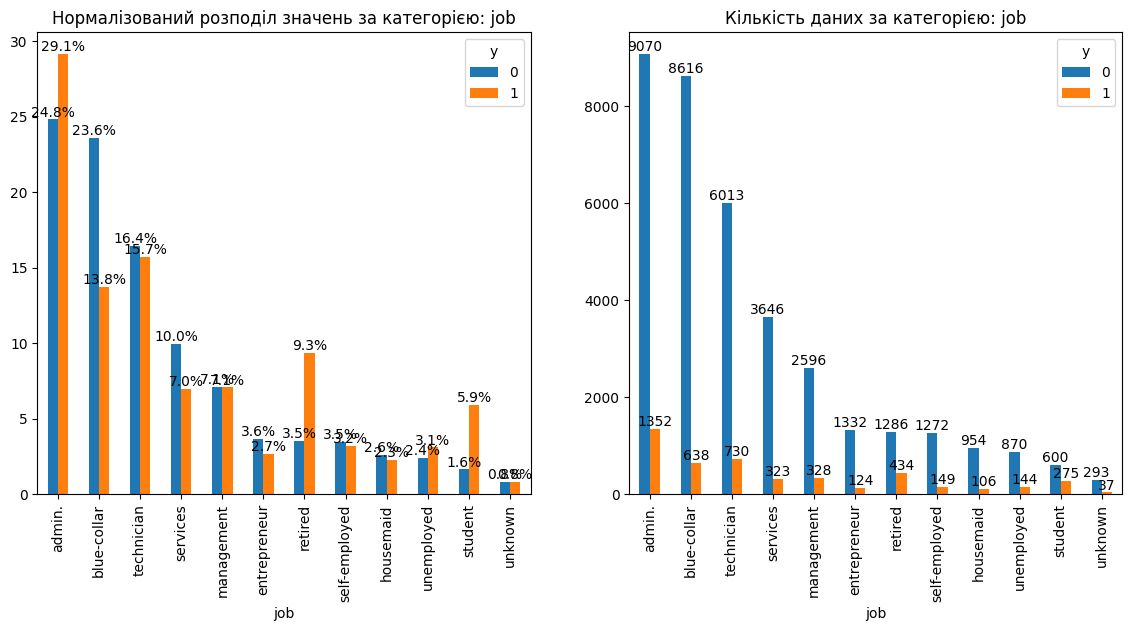

In [ ]:
uni_cat_target_compare(df_bank,'job')

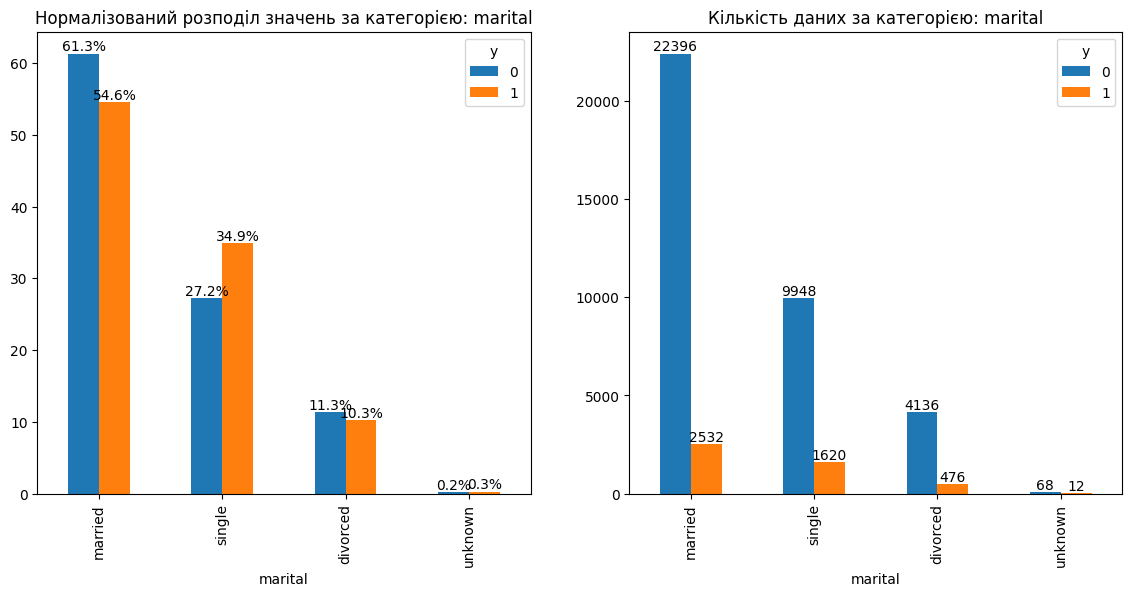

In [ ]:
uni_cat_target_compare(df_bank,'marital')

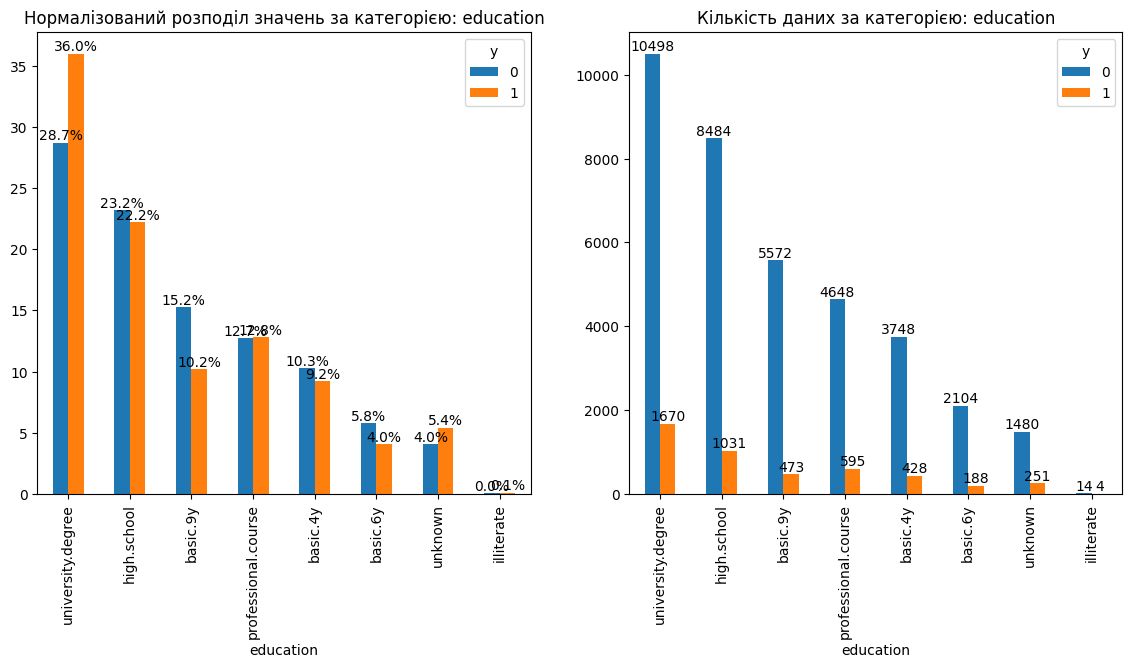

In [ ]:
uni_cat_target_compare(df_bank,'education')

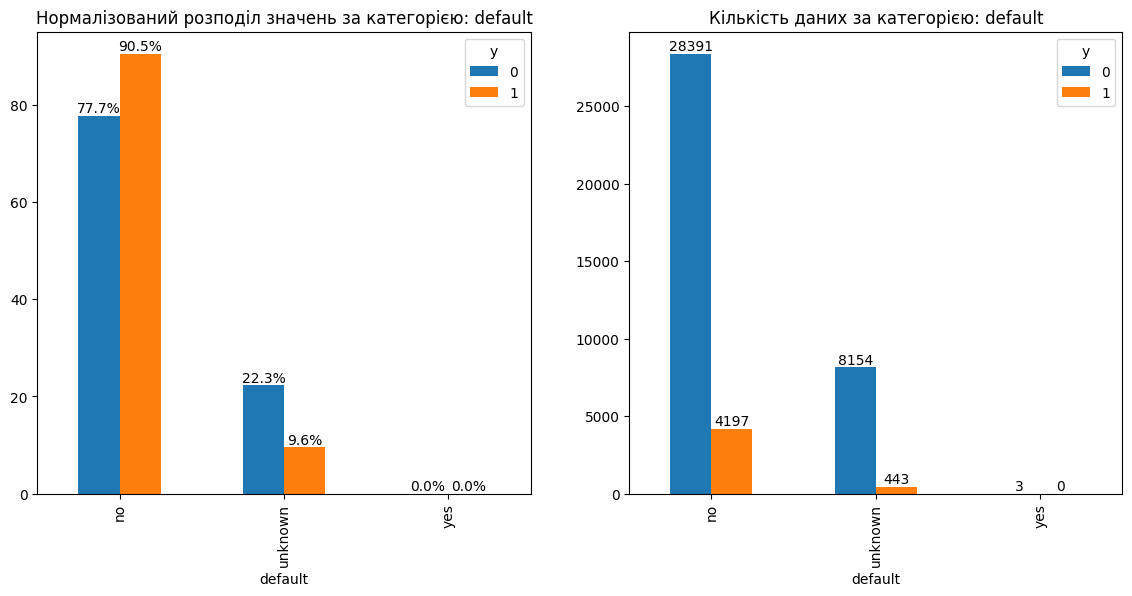

In [ ]:
uni_cat_target_compare(df_bank,'default')

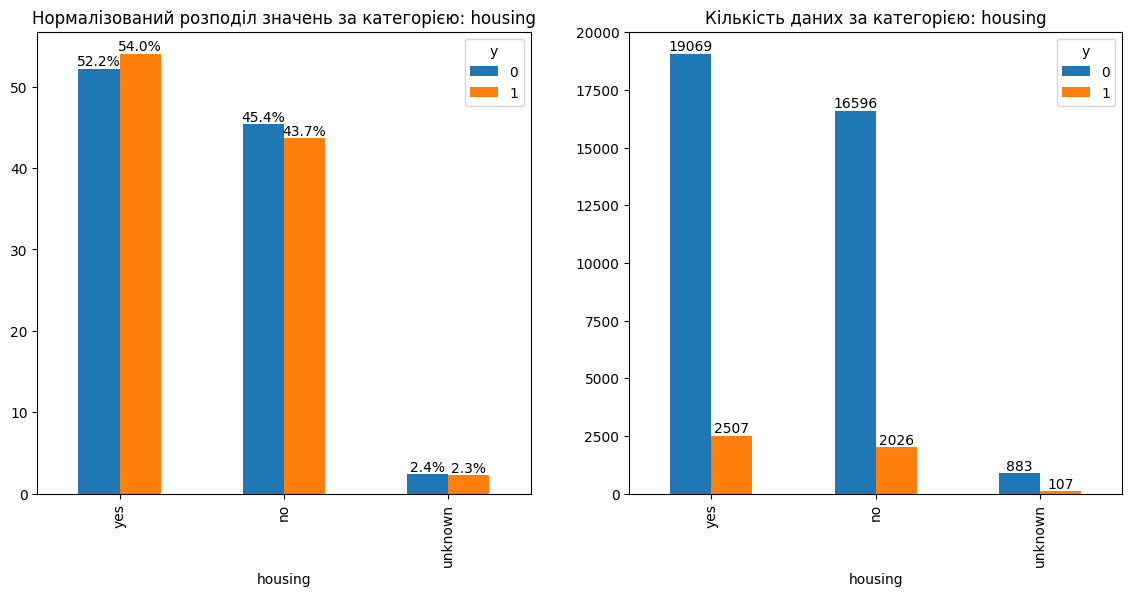

In [ ]:
uni_cat_target_compare(df_bank,'housing')

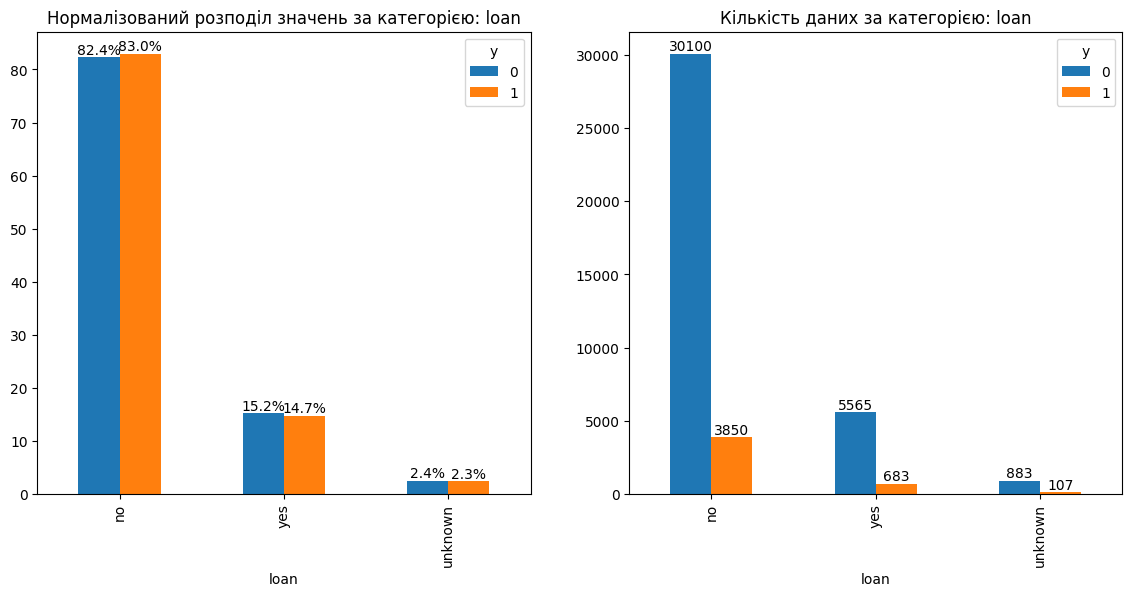

In [ ]:
uni_cat_target_compare(df_bank,'loan')

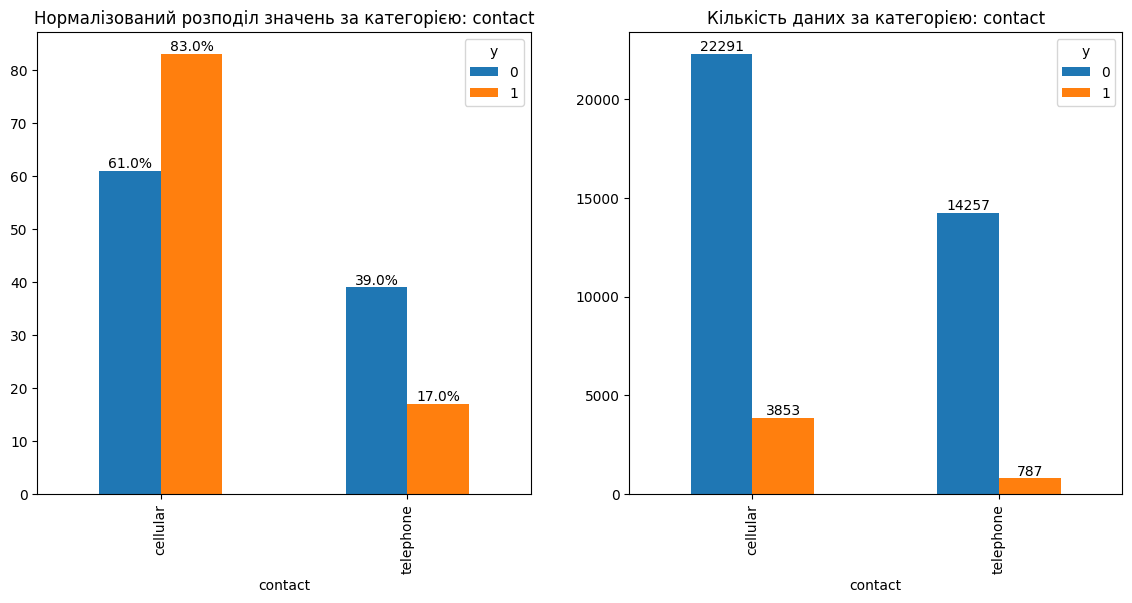

In [ ]:
uni_cat_target_compare(df_bank,'contact')

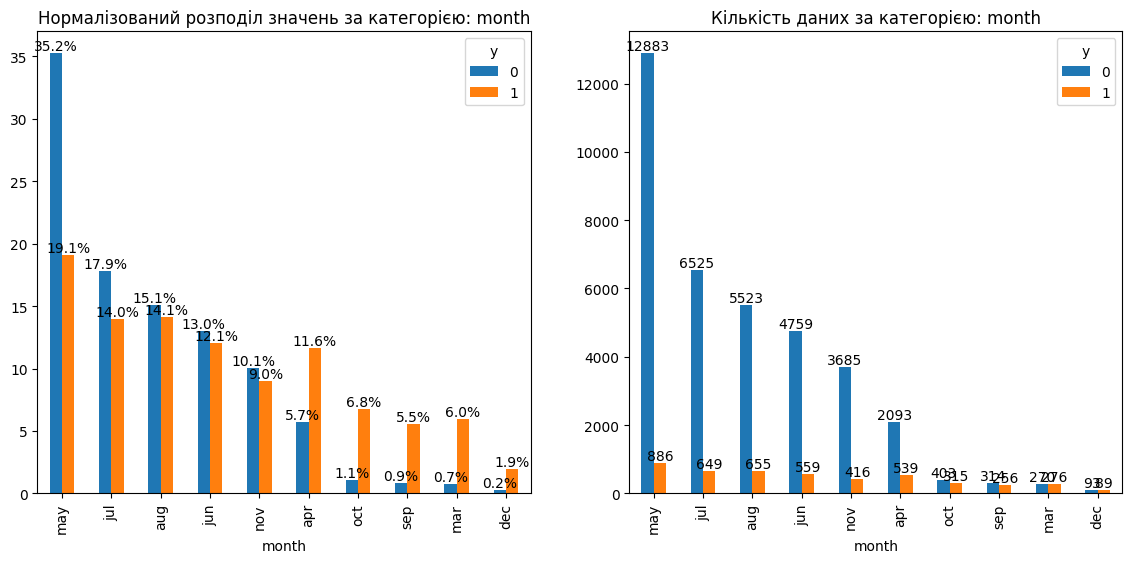

In [ ]:
uni_cat_target_compare(df_bank,'month')

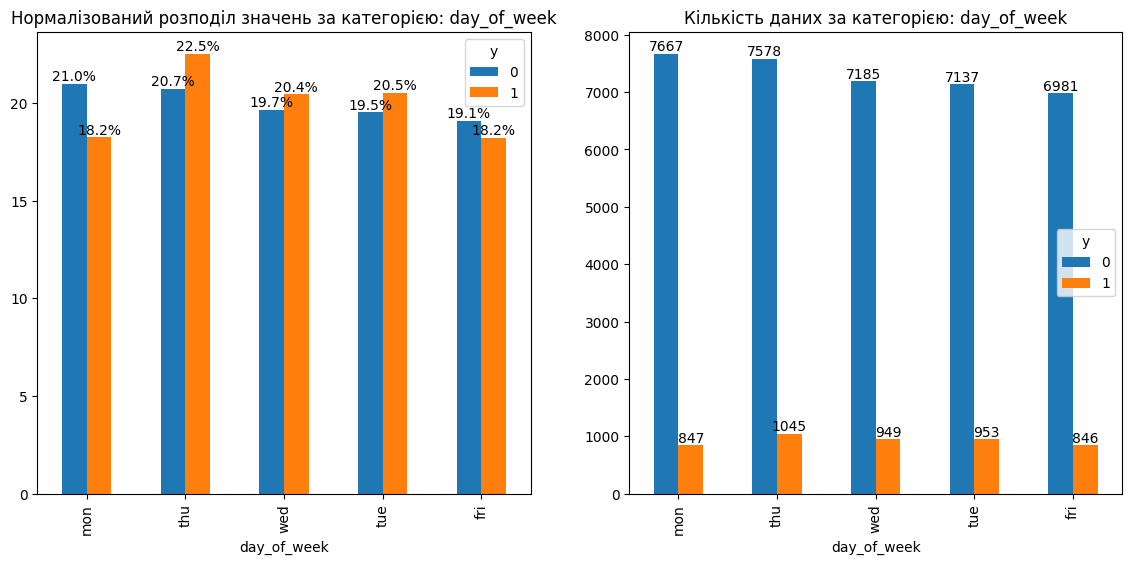

In [ ]:
uni_cat_target_compare(df_bank,'day_of_week')

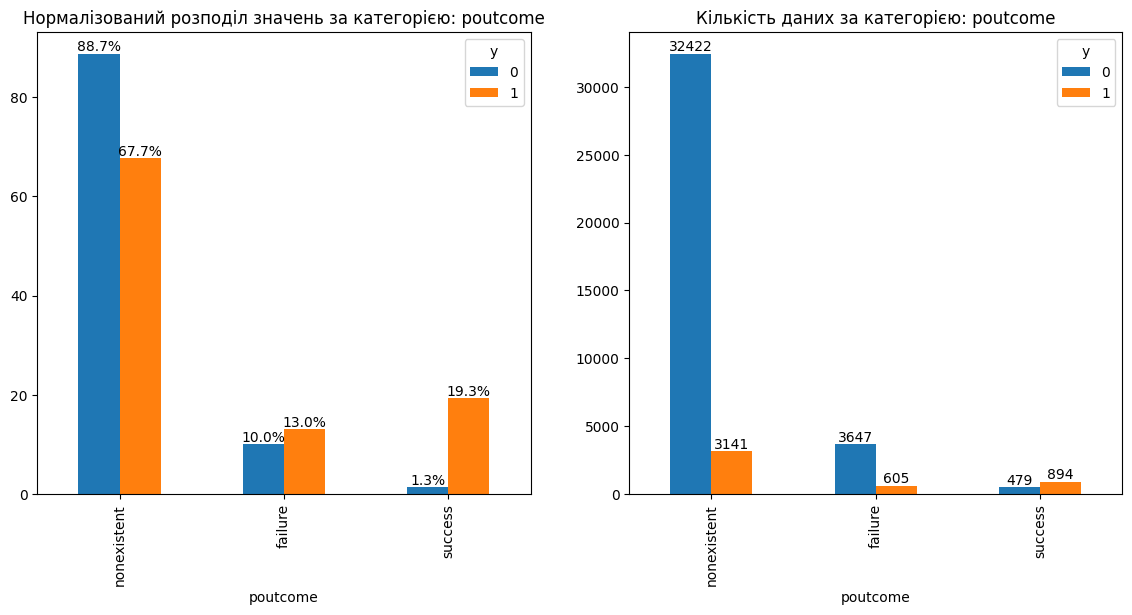

In [ ]:
uni_cat_target_compare(df_bank,'poutcome')

###висновки
1. всі категоріальні колонки не містять пропусків
2. окрім колонок job, education, month інші містять не багато унікальних значень - це допоможе при виборі методу кодування категоріальних колонок
3. колонку month -можна закодувати відповідним порядковим числом місяця року, аналогічно до day_of_week
4. колонку education можна кодувати - від 0 до 6 по зростанню рівня навчання - від невідомо до університету
5. колонки housing, loan, day_of_week не мають вплива на таргет
6. default містить дуже мало значень yes всього 3
, тому можна їх або видалити або додати до unknown
7. вагомими є наступні колонки: poutcome, job, education, default, contact, month


## числові ознаки

###подивимось на розподіл даних - середнє, медіану та перцентилі

In [ ]:
numeric_df = df_bank.select_dtypes(include=['number'])
numeric_df = numeric_df.drop(columns=['y', 'duration'])
stats = numeric_df.describe().T


stats['median'] = numeric_df.median()
stats['missing_values'] = numeric_df.isnull().sum()

result = stats[['missing_values', 'mean', 'median', '25%', '50%', '75%']]
result_rounded = result.round(2)
print(result_rounded)


                missing_values     mean   median      25%      50%      75%
age                          0    40.02    38.00    32.00    38.00    47.00
campaign                     0     2.57     2.00     1.00     2.00     3.00
pdays                        0   962.48   999.00   999.00   999.00   999.00
previous                     0     0.17     0.00     0.00     0.00     0.00
emp.var.rate                 0     0.08     1.10    -1.80     1.10     1.40
cons.price.idx               0    93.58    93.75    93.08    93.75    93.99
cons.conf.idx                0   -40.50   -41.80   -42.70   -41.80   -36.40
euribor3m                    0     3.62     4.86     1.34     4.86     4.96
nr.employed                  0  5167.04  5191.00  5099.10  5191.00  5228.10


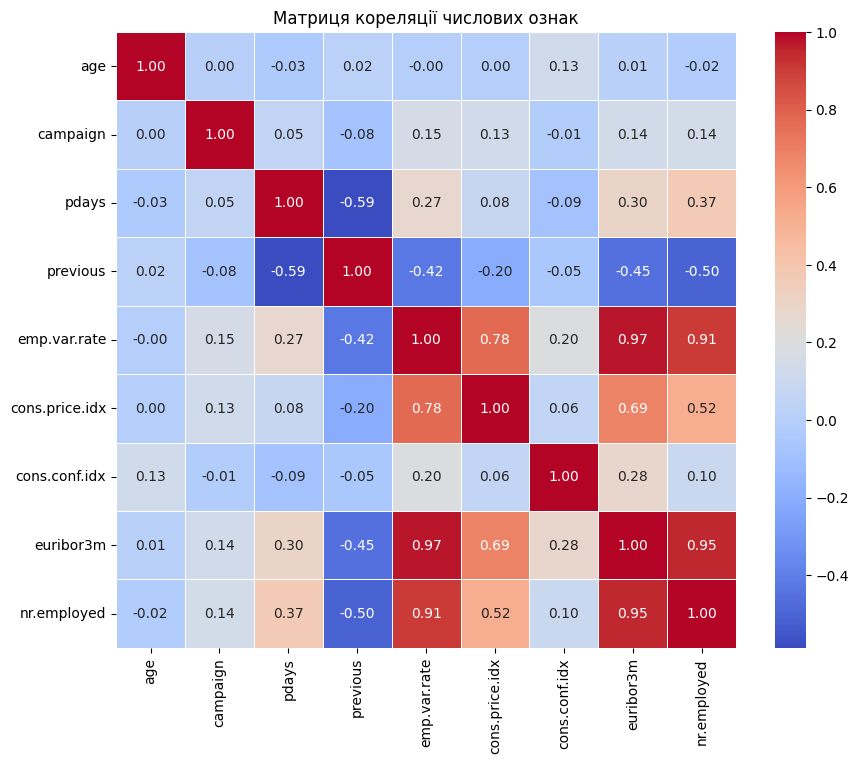

In [ ]:
# рахуємо матрицю кореляції
corr_matrix = numeric_df.corr()

# будуємо Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Матриця кореляції числових ознак')
plt.show()

In [ ]:
# pdays (кількість днів після минулого контакту) - 999 заглушка і колонку краще зробити 0 - не контактували, 1 - контактували
df_bank['pdays'] = np.where(df_bank['pdays'] == 999, 0, 1)

Text(0.5, 0, 'Кількість контактів')

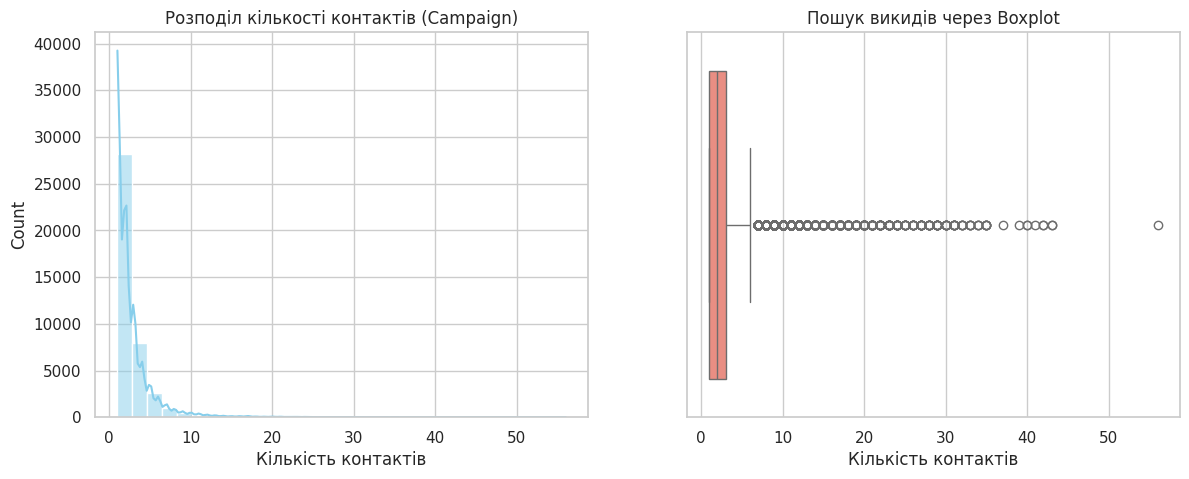

In [ ]:
# питання -campaign - середнє вище за медіану можуть бути викиди , потрібно перевірити мах. значення.
sns.set_theme(style="whitegrid")

# Створення фігури з двома графіками
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 1. Гістограма
sns.histplot(df_bank['campaign'], bins=30, kde=True, ax=ax1, color='skyblue')
ax1.set_title('Розподіл кількості контактів (Campaign)')
ax1.set_xlabel('Кількість контактів')

# 2. Boxplot
sns.boxplot(x=df_bank['campaign'], ax=ax2, color='salmon')
ax2.set_title('Пошук викидів через Boxplot')
ax2.set_xlabel('Кількість контактів')

In [ ]:
#  так дійсно є викиди, що гарно візуалізуються на графіках вище . нижче проводиму заміну медіаною
Q1 = df_bank['campaign'].quantile(0.25)
Q3 = df_bank['campaign'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Замінюємо викиди на медіану
median_val = df_bank['campaign'].median()
df_bank.loc[df_bank['campaign'] > upper_bound, 'campaign'] = median_val

###висновки по числовим колонкам
1. для pdays - 999 -замінила на 0, інші на - 1. Відповідно була чи ні комунікація
2. наявні викиди в campaign замінила медіаною
3. в euribor3m  наявний великий розкид в даних - але поки залишила без змін
4. nr.employed - серед усіх числових має саме велике значення - треба нормалізувати в подальшому
5. euribor3m , emp.var.rate , nr.employed -  мають дуже сильну кореляцію - для регресії варто залишити лише одну фічу, але регресія є baseline, а LGBM та RF не є чутливими до мультиколінеарності, тому поки залишу всі три змінні.

#вибір методів обробки даних, підготовка та вибір метрики оцінки

###оцінка якості моделі
в якості метрики оцінки буду використовувати F1 оскільки в таргеті наявний дисбаланс класів- тих хто відкрив дипозит набагато менше ніж тих, хто ні.
цікавить якість прогнозу для позитивного класу.


###обробка даних
оскільки дві з моделей вимагають детальної обробки даних, то для регресії та KNN зробимо наступні перетворення
1. зробимо зміни в категоріальних колонках відповідно до висновків в розділі EDA:
  *   колонку month - можна закодувати відповідним порядковим числом місяця року, аналогічно до day_of_week
* колонку education можна кодувати - від 0 до 6 по зростанню рівня навчання - від невідомо до університету


*    default містить дуже мало значень yes всього 3 , тому можна їх або видалити або додати до unknown
2. нормалізуємо числові фічі
3. трансфоруємо категоріальні фічі
4. натренуємо моделі та оцінимо їх якість
5. потім перейдемо до дерев та бустінга

In [ ]:
df_bank = df_bank.drop(columns=[ 'duration'])
df_bank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  campaign        41188 non-null  int64  
 11  pdays           41188 non-null  int64  
 12  previous        41188 non-null  int64  
 13  poutcome        41188 non-null  object 
 14  emp.var.rate    41188 non-null  float64
 15  cons.price.idx  41188 non-null  float64
 16  cons.conf.idx   41188 non-null  float64
 17  euribor3m       41188 non-null 

In [ ]:
#колонку month - можна закодувати відповідним порядковим числом місяця року, аналогічно до day_of_week

month_map = {
    'jan': 1, 'feb': 2, 'mar': 3, 'apr': 4, 'may': 5, 'jun': 6,
    'jul': 7, 'aug': 8, 'sep': 9, 'oct': 10, 'nov': 11, 'dec': 12
}

df_bank['month'] = df_bank['month'].map(month_map)


dow_map = {
    'mon': 1,
    'tue': 2,
    'wed': 3,
    'thu': 4,
    'fri': 5
}

df_bank['day_of_week'] = df_bank['day_of_week'].map(dow_map)


In [ ]:
#колонку education можна кодувати - від 0 до 6 по зростанню рівня навчання - від невідомо до університету
education_map = {
    'illiterate': 0,
    'basic.4y': 1,
    'basic.6y': 2,
    'basic.9y': 3,
    'high.school': 4,
    'professional.course': 5,
    'university.degree': 6,
    'unknown': 3              # Медіанне значення
}

df_bank['education'] = df_bank['education'].map(education_map)

In [ ]:
#default містить дуже мало значень yes всього 3 , тому можна їх або видалити або додати до unknown
df_bank['default'] = df_bank['default'].replace('yes', 'unknown')

In [ ]:
df_bank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  int64  
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  int64  
 9   day_of_week     41188 non-null  int64  
 10  campaign        41188 non-null  int64  
 11  pdays           41188 non-null  int64  
 12  previous        41188 non-null  int64  
 13  poutcome        41188 non-null  object 
 14  emp.var.rate    41188 non-null  float64
 15  cons.price.idx  41188 non-null  float64
 16  cons.conf.idx   41188 non-null  float64
 17  euribor3m       41188 non-null 

In [ ]:
# Створюємо тренувальний і тестовий набори
train_df_, test_df = train_test_split(df_bank, test_size=0.2, random_state=42,stratify=df_bank['y'])

input_cols=list(df_bank.columns)[0:-1]
target_col='y'
test_inputs=test_df[input_cols].copy()
test_targets=test_df[target_col].copy()

In [ ]:
# Додатковий спліт train -> train + val
train_df, val_df = train_test_split(
    train_df_, test_size=0.2, random_state=42, stratify=train_df_['y']
)
train_inputs = train_df[input_cols].copy()
train_targets = train_df[target_col].copy()
val_inputs = val_df[input_cols].copy()
val_targets = val_df[target_col].copy()

In [ ]:
# Виявляємо числові і категоріальні колонки
numeric_cols = train_inputs.select_dtypes(include=np.number).columns.tolist()
categorical_cols = train_inputs.select_dtypes('object').columns.tolist()
# Створюємо трансформери для числових і категоріальних колонок
numeric_transformer = Pipeline(steps=[

    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

# Комбінуємо трансформери для різних типів колонок в один препроцесор
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])


# Функція, щоб передбачати і рахувати метрики
def predict_and_plot(model_pipeline, inputs, targets, name=''):
    preds = model_pipeline.predict(inputs)
    y_pred_proba = model_pipeline.predict_proba(inputs)[:, 1]
    f1 = f1_score(targets, preds)
    print("F1 score: {:.2%}".format(f1))
    fpr, tpr, thresholds = roc_curve(targets, y_pred_proba)


    confusion_matrix_ = confusion_matrix(targets, preds, normalize='true')
    plt.figure()
    sns.heatmap(confusion_matrix_, annot=True, cmap='Blues')
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name))
    plt.show()
    return preds


##логістична регресія

In [ ]:
# Створюємо пайплайн, який спочатку запускає препроцесинг, потім тренуєм модель
model_pipeline_LR = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear', class_weight='balanced'))

])


# Тренуємо пайплайн
model_pipeline_LR.fit(train_inputs, train_targets)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'education', 'month',
                                                   'day_of_week', 'campaign',
                                                   'pdays', 'previous',
                                                   'emp.var.rate',
                                                   'cons.price.idx',
                                                   'cons.conf.idx', 'euribor3m',
                                                   'nr.employed']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['job', 'marital', 'default',
                                                   'housing', 'loan', 'contact',
                                                   'poutcome'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced',
                                    solver='liblinear'))])

F1 score: 40.59%


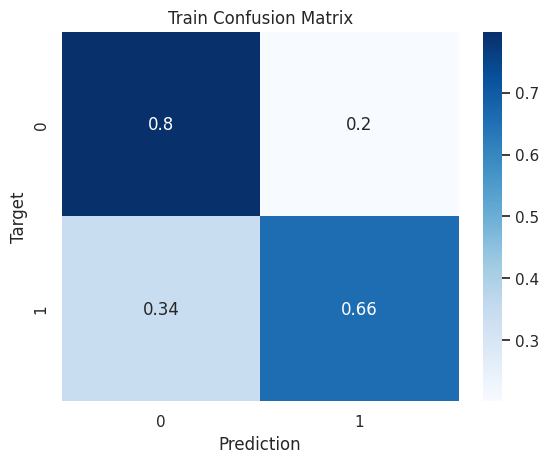

F1 score: 40.46%


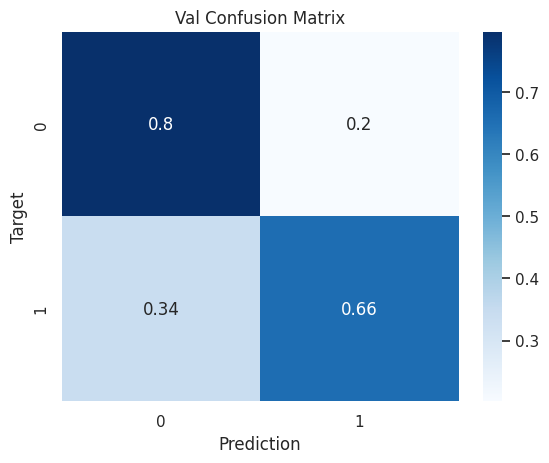

In [ ]:
# Оцінюємо модель на train та test даних
train_preds = predict_and_plot(model_pipeline_LR,train_inputs, train_targets, 'Train')
val_preds = predict_and_plot(model_pipeline_LR,val_inputs, val_targets, 'Val')


# KNN

In [ ]:
# 1. Створюємо базовий пайплайн
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier())
])

# 2. Визначаємо сітку параметрів
params_knn = {
    'classifier__n_neighbors': np.arange(1, 25),
    'classifier__weights': ['uniform', 'distance']
}

# 3. Налаштовуємо GridSearchCV
knn_gs = GridSearchCV(
    full_pipeline,
    params_knn,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

# 4. Навчаємо
knn_gs.fit(train_inputs, train_targets)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('scaler',
                                                                                          StandardScaler())]),
                                                                         ['age',
                                                                          'education',
                                                                          'month',
                                                                          'day_of_week',
                                                                          'campaign',
                                                                          'pdays',
                                                                          'previous',
                                                                          'emp.var.rate',
                                                                          'cons.price.idx',
                                                                          'cons.conf.idx',
                                                                          'euribor3m',
                                                                          'nr.employed']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore',
                                                                                                        sparse_output=False))]),
                                                                         ['job',
                                                                          'marital',
                                                                          'default',
                                                                          'housing',
                                                                          'loan',
                                                                          'contact',
                                                                          'poutcome'])])),
                                       ('classifier', KNeighborsClassifier())]),
             n_jobs=-1,
             param_grid={'classifier__n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24]),
                         'classifier__weights': ['uniform', 'distance']},
             scoring='f1')

F1 score: 47.64%


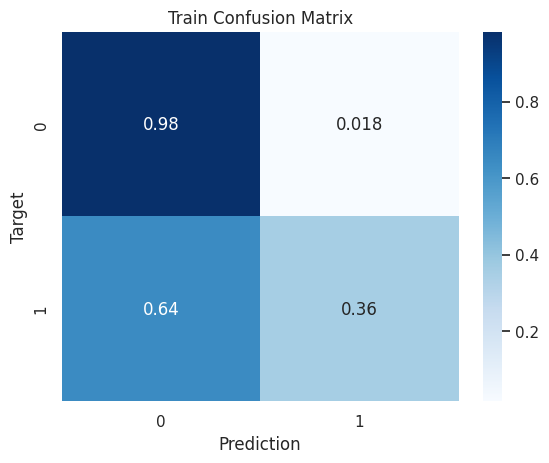

F1 score: 37.62%


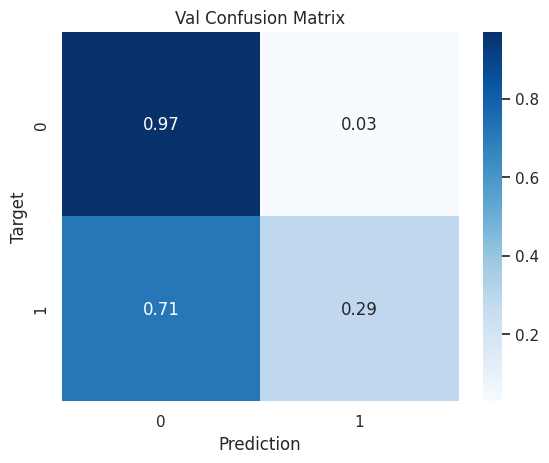

In [ ]:
# Оцінюємо модель
train_preds = predict_and_plot(knn_gs,train_inputs, train_targets, 'Train')
val_preds = predict_and_plot(knn_gs,val_inputs, val_targets, 'Val')

#### KNN - модель гірша за LG. Оскільки даний метод доволі довгий в розрахунках,  спробую інші моделі,  а саме дерева та бустінг.

##RandomForest

In [ ]:
model_pipeline_RF = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
              n_estimators=200,
              max_depth=8,
               max_leaf_nodes=40,
              max_features='sqrt',
              class_weight='balanced',
              random_state=42,
             n_jobs=-1
    ))
])



# Навчання
model_pipeline_RF.fit(train_inputs, train_targets)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'education', 'month',
                                                   'day_of_week', 'campaign',
                                                   'pdays', 'previous',
                                                   'emp.var.rate',
                                                   'cons.price.idx',
                                                   'cons.conf.idx', 'euribor3m',
                                                   'nr.employed']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['job', 'marital', 'default',
                                                   'housing', 'loan', 'contact',
                                                   'poutcome'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced', max_depth=8,
                                        max_leaf_nodes=40, n_estimators=200,
                                        n_jobs=-1, random_state=42))])

F1 score: 47.27%


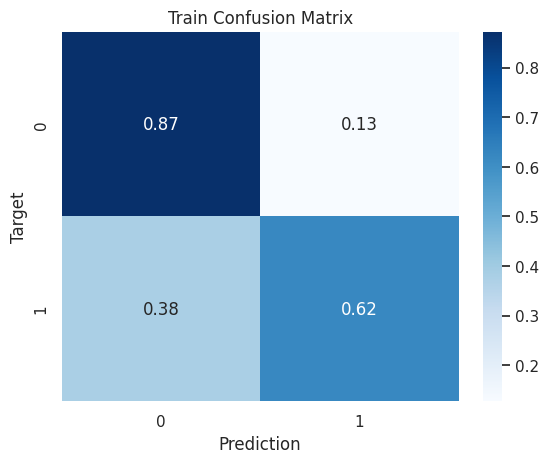

F1 score: 47.13%


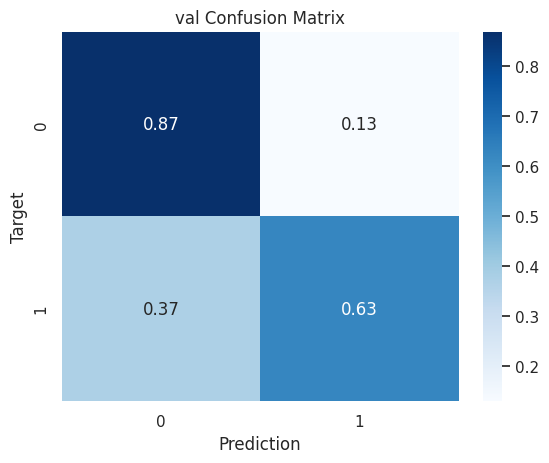

In [ ]:
# Оцінюємо модель
train_preds = predict_and_plot(model_pipeline_RF,train_inputs, train_targets, 'Train')
val_preds = predict_and_plot(model_pipeline_RF,val_inputs, val_targets, 'val')

Наразі результат є кращим ніж KNN. Проведемо тюнінг гіперпараметрів, щоб обрати бест параметри для моделі.

In [ ]:
#визначимо функцію тюнінгу гіперпараметрів для RF
def rf_hyperparameter_experiment(X_train, y_train, X_val, y_val):


    results = {'iter': [], 'val_auc': [], 'val_f1': []}

    # Параметри для перебору
    depths = [5, 10, 15, 20]
    min_samples = [10, 30, 50, 100]

    counter = 0
    best_f1 = 0
    best_params = {}

    print(f"{'Iter':<5} | {'Depth':<5} | {'MinLeaf':<7} | {'Val AUC':<10} | {'Val F1':<10}")
    print("-" * 55)

    for depth in depths:
        for min_leaf in min_samples:
            counter += 1

            # Навчання

            model = RandomForestClassifier(
                n_estimators=100,
                max_depth=depth,
                min_samples_leaf=min_leaf,
                 max_features='sqrt',
                class_weight='balanced',
                random_state=42,
                n_jobs=-1
            )
            model.fit(X_train, y_train)

            # Метрики
            val_probs = model.predict_proba(X_val)[:, 1]
            val_preds = model.predict(X_val)

            v_auc = roc_auc_score(y_val, val_probs)
            v_f1 = f1_score(y_val, val_preds)

            results['iter'].append(counter)
            results['val_auc'].append(v_auc)
            results['val_f1'].append(v_f1)

            if v_f1 > best_f1:
                best_f1 = v_f1
                best_params = {'depth': depth, 'min_leaf': min_leaf, 'f1': v_f1, 'auc': v_auc}

            print(f"{counter:<5} | {depth:<5} | {min_leaf:<7} | {v_auc:.4f}    | {v_f1:.4f}")

    # Графік порівняння
    plt.figure(figsize=(10, 5))
    plt.plot(results['iter'], results['val_auc'], label='Val AUC', marker='o')
    plt.plot(results['iter'], results['val_f1'], label='Val F1', marker='s', color='green')
    plt.title('Random Forest Tuning')
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()
    return best_params

Iter  | Depth | MinLeaf | Val AUC    | Val F1    
-------------------------------------------------------
1     | 5     | 10      | 0.7963    | 0.4453
2     | 5     | 30      | 0.7969    | 0.4502
3     | 5     | 50      | 0.7964    | 0.4417
4     | 5     | 100     | 0.7955    | 0.4364
5     | 10    | 10      | 0.8054    | 0.4859
6     | 10    | 30      | 0.8053    | 0.4769
7     | 10    | 50      | 0.8035    | 0.4680
8     | 10    | 100     | 0.8025    | 0.4552
9     | 15    | 10      | 0.8047    | 0.4949
10    | 15    | 30      | 0.8040    | 0.4807
11    | 15    | 50      | 0.8038    | 0.4737
12    | 15    | 100     | 0.8020    | 0.4583
13    | 20    | 10      | 0.8062    | 0.5030
14    | 20    | 30      | 0.8043    | 0.4769
15    | 20    | 50      | 0.8051    | 0.4715
16    | 20    | 100     | 0.8018    | 0.4576


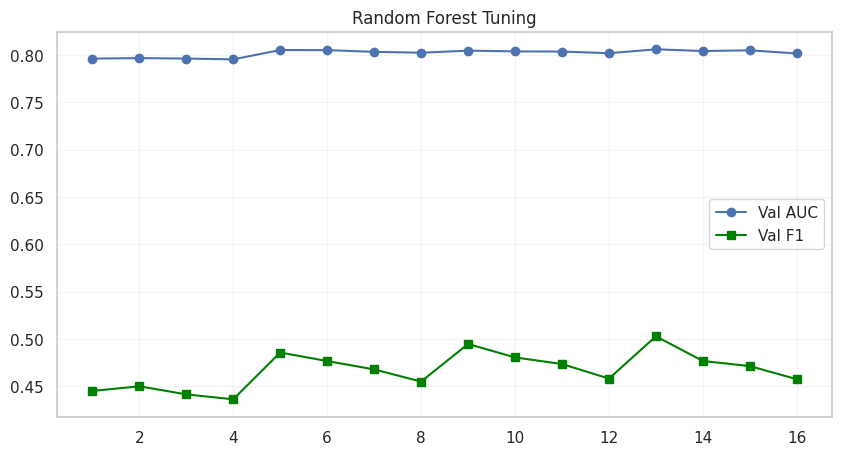

{'depth': 20,
 'min_leaf': 10,
 'f1': 0.5030203185063152,
 'auc': np.float64(0.8061558816154808)}

In [ ]:
X_train_RF = preprocessor.fit_transform(train_inputs)
X_val_RF   = preprocessor.transform(val_inputs)

rf_hyperparameter_experiment(X_train_RF, train_targets, X_val_RF, val_targets)



In [ ]:
model_pipeline_RF_best = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
              n_estimators=100,
              max_depth=20,
               min_samples_leaf=10,
              max_features='sqrt',
              class_weight='balanced',
              random_state=42,
             n_jobs=-1
    ))
])



# Навчання
model_pipeline_RF_best.fit(train_inputs, train_targets)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'education', 'month',
                                                   'day_of_week', 'campaign',
                                                   'pdays', 'previous',
                                                   'emp.var.rate',
                                                   'cons.price.idx',
                                                   'cons.conf.idx', 'euribor3m',
                                                   'nr.employed']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['job', 'marital', 'default',
                                                   'housing', 'loan', 'contact',
                                                   'poutcome'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced', max_depth=20,
                                        min_samples_leaf=10, n_jobs=-1,
                                        random_state=42))])

F1 score: 53.34%


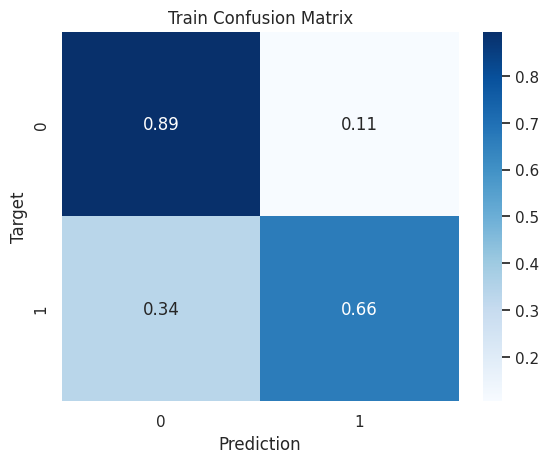

F1 score: 50.30%


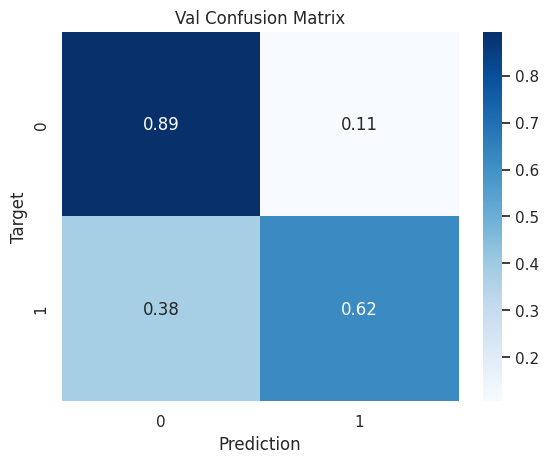

In [ ]:
train_preds = predict_and_plot(model_pipeline_RF_best,train_inputs, train_targets, 'Train')
val_preds = predict_and_plot(model_pipeline_RF_best,val_inputs, val_targets, 'Val')

###на даному етапі накращими параметрами є
depth= 20, min_leaf = 10 і при цьому f1= 0.5030,  що поки є найкращим результатом.

###подивимось на топ 10 важливих ознак, а також видалимо не важливі

                      feature  importance
11           num__nr.employed    0.227542
10             num__euribor3m    0.201457
7           num__emp.var.rate    0.138344
9          num__cons.conf.idx    0.077455
2                  num__month    0.051192
8         num__cons.price.idx    0.050263
5                  num__pdays    0.047463
40      cat__poutcome_success    0.033803
6               num__previous    0.030007
39  cat__poutcome_nonexistent    0.019476


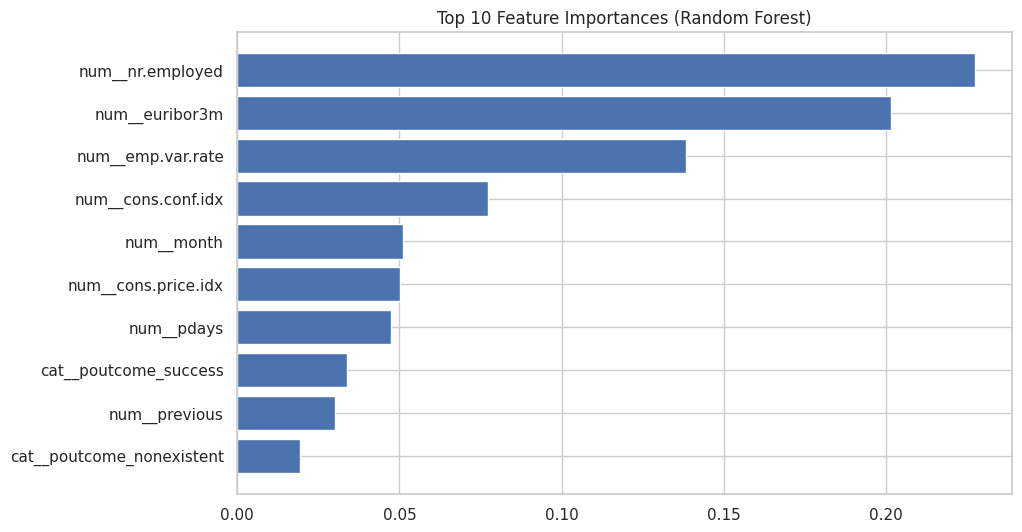

In [ ]:
feature_names = model_pipeline_RF.named_steps['preprocessor'].get_feature_names_out()

# Витягуємо саму важливість ознак з моделі лісу
importances = model_pipeline_RF.named_steps['classifier'].feature_importances_

# Створюємо зручний DataFrame
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

# Виводимо ТОП-10 ознак
print(feature_importance_df.head(10))

# Візуалізація
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['feature'][:10], feature_importance_df['importance'][:10])
plt.gca().invert_yaxis()
plt.title('Top 10 Feature Importances (Random Forest)')
plt.show()

In [ ]:
feature_names = model_pipeline_RF.named_steps['preprocessor'].get_feature_names_out()
importances = model_pipeline_RF.named_steps['classifier'].feature_importances_

# Створюємо список "корисних" ознак
threshold = 0.001
important_features = feature_names[importances >= threshold]
unimportant_features = feature_names[importances < threshold]

print(f"Видаляємо {len(unimportant_features)} ознак.")
print(f"Залишаємо {len(important_features)} ознак.")

Видаляємо 14 ознак.
Залишаємо 27 ознак.


видалимо неважливі фічі і перетренуємо модель


Iter  | Depth | MinLeaf | Val AUC    | Val F1    
-------------------------------------------------------
1     | 5     | 10      | 0.7974    | 0.4572
2     | 5     | 30      | 0.7975    | 0.4594
3     | 5     | 50      | 0.7985    | 0.4555
4     | 5     | 100     | 0.7958    | 0.4551
5     | 10    | 10      | 0.8076    | 0.4866
6     | 10    | 30      | 0.8070    | 0.4760
7     | 10    | 50      | 0.8074    | 0.4746
8     | 10    | 100     | 0.8037    | 0.4620
9     | 15    | 10      | 0.8061    | 0.4970
10    | 15    | 30      | 0.8097    | 0.4851
11    | 15    | 50      | 0.8064    | 0.4756
12    | 15    | 100     | 0.8054    | 0.4606
13    | 20    | 10      | 0.8067    | 0.4981
14    | 20    | 30      | 0.8072    | 0.4843
15    | 20    | 50      | 0.8066    | 0.4735
16    | 20    | 100     | 0.8056    | 0.4615


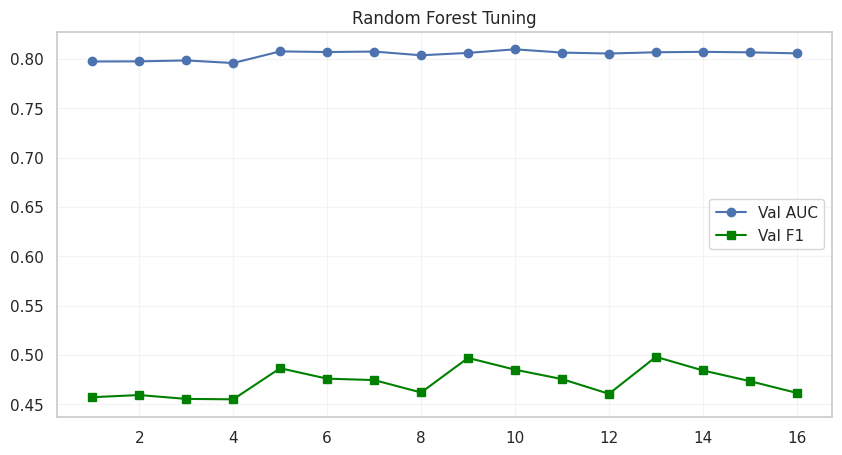

{'depth': 20,
 'min_leaf': 10,
 'f1': 0.49810503519220356,
 'auc': np.float64(0.8067147383306108)}

In [ ]:
set_config(transform_output="pandas")

X_train_RF = preprocessor.fit_transform(train_inputs)
X_val_RF   = preprocessor.transform(val_inputs)

train_inputs_RF = X_train_RF.drop(columns=unimportant_features)
val_inputs_RF   = X_val_RF.drop(columns=unimportant_features)

rf_hyperparameter_experiment(train_inputs_RF, train_targets, val_inputs_RF, val_targets)


після видалення неважливих фічей  якість моделі знизилась і тому я перейду до бустінгу і потім порівняю всі результати на валідаційних даних і фінальну модель протестую на тестовій вибірці

##LGBMClassifier

In [ ]:
# 1. Створюємо фінальний пайплайн
model_pipeline_LGBM = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('selector', SelectFromModel(LGBMClassifier(n_estimators=100, random_state=42), threshold='median')),
       ('model', LGBMClassifier(
        n_estimators=1000,
        learning_rate=0.02,
        max_depth=6,
        num_leaves=55,
        #is_unbalance=True,
        scale_pos_weight=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbosity=-1,
        n_jobs=-1
    ))
])

# 2. Тренуємо весь пайплайн одразу
model_pipeline_LGBM.fit(train_inputs, train_targets)

[LightGBM] [Info] Number of positive: 2970, number of negative: 23390
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004140 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 381
[LightGBM] [Info] Number of data points in the train set: 26360, number of used features: 41
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.112671 -> initscore=-2.063747
[LightGBM] [Info] Start training from score -2.063747


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'education', 'month',
                                                   'day_of_week', 'campaign',
                                                   'pdays', 'previous',
                                                   'emp.var.rate',
                                                   'cons.price.idx',
                                                   'cons.conf.idx', 'euribor3m',
                                                   'nr.employed']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['job', 'marital', 'default',
                                                   'housing', 'loan', 'contact',
                                                   'poutcome'])])),
                ('selector',
                 SelectFromModel(estimator=LGBMClassifier(random_state=42),
                                 threshold='median')),
                ('model',
                 LGBMClassifier(colsample_bytree=0.8, learning_rate=0.02,
                                max_depth=6, n_estimators=1000, n_jobs=-1,
                                num_leaves=55, random_state=42,
                                scale_pos_weight=6, subsample=0.8,
                                verbosity=-1))])

F1 score: 56.39%


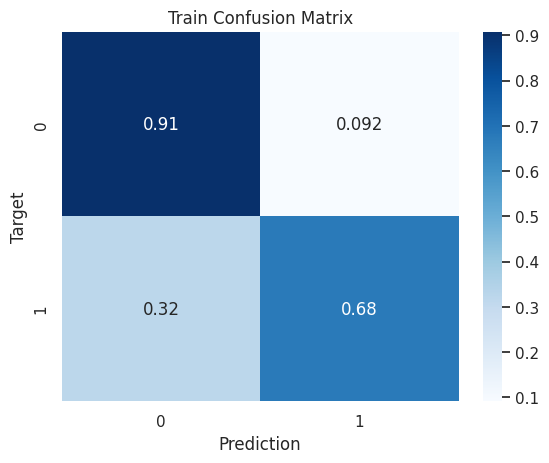

F1 score: 50.42%


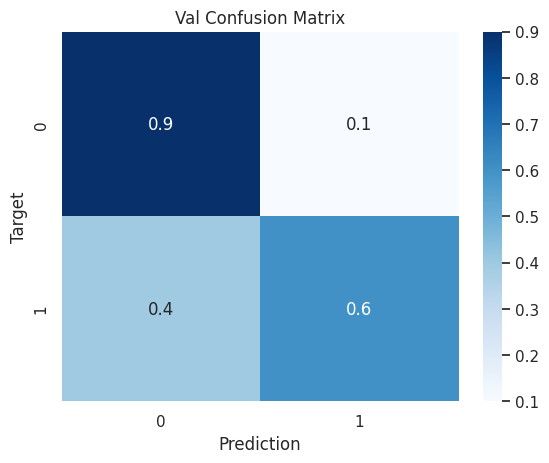

In [ ]:
train_preds = predict_and_plot(model_pipeline_LGBM,train_inputs, train_targets, 'Train')
val_preds = predict_and_plot(model_pipeline_LGBM,val_inputs, val_targets, 'Val')

In [ ]:
#подивимось на метрики при зміні thresholds
probs = model_pipeline_LGBM.predict_proba(val_inputs)[:, 1]

thresholds = [0.50, 0.55, 0.62, 0.65, 0.68, 0.70, 0.8]

for threshold in thresholds:
    preds = (probs > threshold).astype(int)

    precision = precision_score(val_targets, preds)
    recall = recall_score(val_targets, preds)
    f1 = f1_score(val_targets, preds)
    print(f"Поріг: {threshold:.2f} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f}")



Поріг: 0.50 | Precision: 0.4336 | Recall: 0.6024 | F1: 0.5042
Поріг: 0.55 | Precision: 0.4499 | Recall: 0.5755 | F1: 0.5050
Поріг: 0.62 | Precision: 0.4831 | Recall: 0.5377 | F1: 0.5089
Поріг: 0.65 | Precision: 0.4942 | Recall: 0.5189 | F1: 0.5062
Поріг: 0.68 | Precision: 0.5142 | Recall: 0.4892 | F1: 0.5014
Поріг: 0.70 | Precision: 0.5228 | Recall: 0.4636 | F1: 0.4914
Поріг: 0.80 | Precision: 0.5874 | Recall: 0.2898 | F1: 0.3881


###RandomizedSearchCV

In [ ]:
param_dist = {
    'model__n_estimators': [500, 1000, 1500],
    'model__learning_rate': [0.01, 0.02, 0.05],
    'model__max_depth': [4, 6, 8, 10],
    'model__num_leaves': [20, 31, 63, 127],
    'model__scale_pos_weight': [5, 8, 10, 12],
    'model__subsample': [0.7, 0.8, 0.9],
    'model__colsample_bytree': [0.6, 0.8, 1.0]
}

random_search = RandomizedSearchCV(
    model_pipeline_LGBM,
    param_distributions=param_dist,
    n_iter=20,
    scoring='f1',
    cv=3,
    n_jobs=-1,
    random_state=42
)

random_search.fit(train_inputs, train_targets)
best_model_RS = random_search.best_estimator_
print("Найкращі параметри (RandomSearch):", random_search.best_params_)


Найкращі параметри (RandomSearch): {'model__subsample': 0.8, 'model__scale_pos_weight': 5, 'model__num_leaves': 127, 'model__n_estimators': 1000, 'model__max_depth': 4, 'model__learning_rate': 0.02, 'model__colsample_bytree': 1.0}


In [ ]:
#подивимось на метрики при зміні thresholds
probs = best_model_RS.predict_proba(val_inputs)[:, 1]

thresholds = [0.50, 0.55, 0.62, 0.65, 0.68, 0.70, 0.8]

for threshold in thresholds:
    preds = (probs > threshold).astype(int)

    precision = precision_score(val_targets, preds)
    recall = recall_score(val_targets, preds)
    f1 = f1_score(val_targets, preds)
    print(f"Поріг: {threshold:.2f} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f}")



Поріг: 0.50 | Precision: 0.4389 | Recall: 0.5997 | F1: 0.5068
Поріг: 0.55 | Precision: 0.4539 | Recall: 0.5836 | F1: 0.5106
Поріг: 0.62 | Precision: 0.4858 | Recall: 0.5526 | F1: 0.5170
Поріг: 0.65 | Precision: 0.4968 | Recall: 0.5243 | F1: 0.5102
Поріг: 0.68 | Precision: 0.5229 | Recall: 0.4771 | F1: 0.4989
Поріг: 0.70 | Precision: 0.5462 | Recall: 0.4461 | F1: 0.4911
Поріг: 0.80 | Precision: 0.6195 | Recall: 0.2830 | F1: 0.3885


###hyperopt

In [ ]:
def objective(params):
    model_pipeline_LGBM.set_params(
        model__n_estimators=int(params['n_estimators']),
        model__max_depth=int(params['max_depth']),
        model__num_leaves=int(params['num_leaves']),
        model__learning_rate=params['learning_rate'],
        model__scale_pos_weight=params['scale_pos_weight']
    )

    score = cross_val_score(model_pipeline_LGBM, train_inputs, train_targets, cv=3, scoring='f1').mean()
    return {'loss': -score, 'status': STATUS_OK}

space = {
    'n_estimators': hp.quniform('n_estimators', 500, 2000, 100),
    'max_depth': hp.quniform('max_depth', 4, 12, 1),
    'num_leaves': hp.quniform('num_leaves', 20, 150, 1),
    'learning_rate': hp.loguniform('learning_rate', np.log(0.005), np.log(0.1)),
    'scale_pos_weight': hp.quniform('scale_pos_weight', 5, 15, 1)
}

best = fmin(
    fn=objective, space=space, algo=tpe.suggest, max_evals=30,
    trials=Trials(),
    rstate=np.random.default_rng(42)
)
print("Найкращі параметри (Hyperopt):", best)


100%|██████████| 30/30 [07:15<00:00, 14.53s/trial, best loss: -0.48986323071189314]
Найкращі параметри (Hyperopt): {'learning_rate': np.float64(0.005354733491750849), 'max_depth': np.float64(4.0), 'n_estimators': np.float64(1900.0), 'num_leaves': np.float64(61.0), 'scale_pos_weight': np.float64(5.0)}


In [ ]:
final_model_hyperopt = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('selector', SelectFromModel(LGBMClassifier(n_estimators=100, random_state=42), threshold='1.25*mean')),
    ('model', LGBMClassifier(
        n_estimators=int(best['n_estimators']),
        learning_rate=best['learning_rate'],
        max_depth=int(best['max_depth']),
        num_leaves=int(best['num_leaves']),
        scale_pos_weight=best['scale_pos_weight'],
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbosity=-1
    ))
])


final_model_hyperopt.fit(train_inputs, train_targets)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'education', 'month',
                                                   'day_of_week', 'campaign',
                                                   'pdays', 'previous',
                                                   'emp.var.rate',
                                                   'cons.price.idx',
                                                   'cons.conf.idx', 'euribor3m',
                                                   'nr.employed']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=F...
                                                   'housing', 'loan', 'contact',
                                                   'poutcome'])])),
                ('selector',
                 SelectFromModel(estimator=LGBMClassifier(random_state=42),
                                 threshold='1.25*mean')),
                ('model',
                 LGBMClassifier(colsample_bytree=0.8,
                                learning_rate=np.float64(0.005354733491750849),
                                max_depth=4, n_estimators=1900, num_leaves=61,
                                random_state=42,
                                scale_pos_weight=np.float64(5.0), subsample=0.8,
                                verbosity=-1))])

In [ ]:
#подивимось на метрики при зміні thresholds
probs = final_model_hyperopt.predict_proba(val_inputs)[:, 1]

thresholds = [0.50, 0.55, 0.62, 0.65, 0.68, 0.70]

for threshold in thresholds:
    preds = (probs > threshold).astype(int)

    precision = precision_score(val_targets, preds)
    recall = recall_score(val_targets, preds)
    f1 = f1_score(val_targets, preds)
    print(f"Поріг: {threshold:.2f} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f}")



Поріг: 0.50 | Precision: 0.4196 | Recall: 0.6011 | F1: 0.4942
Поріг: 0.55 | Precision: 0.4324 | Recall: 0.5863 | F1: 0.4977
Поріг: 0.62 | Precision: 0.4504 | Recall: 0.5633 | F1: 0.5006
Поріг: 0.65 | Precision: 0.4580 | Recall: 0.5512 | F1: 0.5003
Поріг: 0.68 | Precision: 0.4729 | Recall: 0.5283 | F1: 0.4990
Поріг: 0.70 | Precision: 0.4814 | Recall: 0.4892 | F1: 0.4853


#Таблиця з результатами моделей

In [ ]:
# 1. Словник з  моделями
models_to_compare = {
    "Baseline LGBM": model_pipeline_LGBM,
    "Randomized Search LGBM": best_model_RS,
    "Hyperopt LGBM": final_model_hyperopt,
    "RandomForest" :model_pipeline_RF_best,
    "LRegression": model_pipeline_LR,
    "KNN":knn_gs
}

# 2. Функція для збору метрик
def get_metrics(model, inputs, targets, threshold=0.55):
    probs = model.predict_proba(inputs)[:, 1]
    preds = (probs > threshold).astype(int)
    return {
        'F1': f1_score(targets, preds),
        'Precision': precision_score(targets, preds),
        'Recall': recall_score(targets, preds)
    }

# 3. Цикл для формування таблиці
results = []
threshold = 0.55

for name, model in models_to_compare.items():
    # Метрики на трейні
    train_m = get_metrics(model, train_inputs, train_targets, threshold)
    # Метрики на val
    val_m = get_metrics(model, val_inputs, val_targets, threshold)
    # Метрики на тесті
    test_m = get_metrics(model, test_inputs, test_targets, threshold)

    results.append({
        'Model Name': name,
        'Train F1': train_m['F1'],
        'Val F1': val_m['F1'],
        'Test F1': test_m['F1'],
        'Test Precision': test_m['Precision'],
        'Test Recall': test_m['Recall']
    })

# 4. Вивід таблиці
df_results = pd.DataFrame(results)
print(df_results.round(3).to_markdown(index=False))


| Model Name             |   Train F1 |   Val F1 |   Test F1 |   Test Precision |   Test Recall |
|:-----------------------|-----------:|---------:|----------:|-----------------:|--------------:|
| Baseline LGBM          |      0.569 |    0.505 |     0.52  |            0.464 |         0.593 |
| Randomized Search LGBM |      0.521 |    0.511 |     0.525 |            0.468 |         0.599 |
| Hyperopt LGBM          |      0.504 |    0.498 |     0.517 |            0.455 |         0.599 |
| RandomForest           |      0.517 |    0.509 |     0.524 |            0.454 |         0.62  |
| LRegression            |      0.432 |    0.431 |     0.451 |            0.346 |         0.645 |
| KNN                    |      0.476 |    0.376 |     0.379 |            0.584 |         0.28  |


### найкращою є модель Randomized Search LGBM
ця модель має:
1.  найвищий показник Test F1 (0.525). Це означає, що вона робить найменше помилок у сукупності.
Варто зауважити, що модель Baseline LGBM має значно вищий Train F1 (0.57) порівняно з обраною моделлю (0.52), що є ознакою перенавчання. Натомість Randomized Search LGBM показує мінімальне відхилення
між Train (0.52), Val (0.51) і Test (0.525) - це свідчить про кращу узагальнювальну здатність моделі.
2.  Precision (~0.47). Для банку це означає, що майже кожен другий дзвінок буде успішним.


##аналіз впливу ознак на передбачення з допомогою бібліотеки SHAP для моделі Randomized Search LGBM

In [ ]:
# 1. Витягуємо трансформовані дані (після обробки та відбору ознак)
preprocessor = best_model_RS.named_steps['preprocessor']
selector = best_model_RS.named_steps['selector']
lgbm_model = best_model_RS.named_steps['model']

X_test_proc = preprocessor.transform(test_inputs)
X_test_sel = selector.transform(X_test_proc)

feature_names = preprocessor.get_feature_names_out()
selected_features = feature_names[selector.get_support()]

X_shap = pd.DataFrame(X_test_sel, columns=selected_features)

# 2. Розрахунок SHAP values
explainer = shap.TreeExplainer(lgbm_model)
shap_values = explainer.shap_values(X_shap)


if isinstance(shap_values, list):
    shap_to_plot = shap_values[1]
else:
    shap_to_plot = shap_values

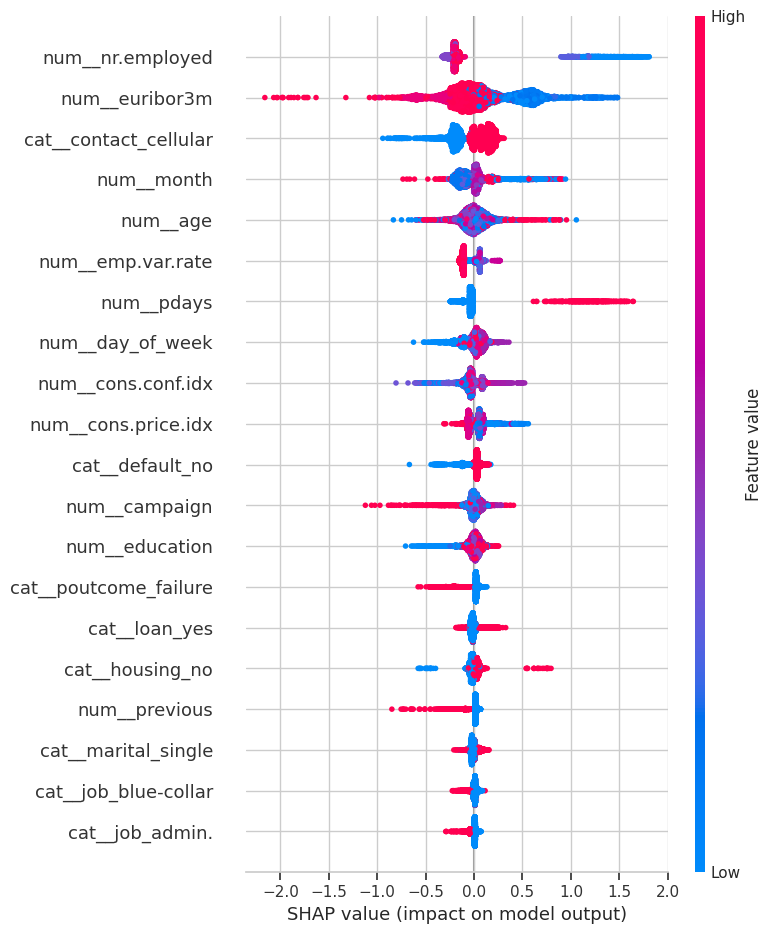

In [ ]:
shap.summary_plot(shap_to_plot, X_shap)

1. найсильнішими фічами є nr.employed та euribor3m аналогічо до того самого списку що попередньо виводила для RF. Видно, що низькі значення цих показників сильно зміщують прогноз праворуч.
2. наявність мобільного телефону (cellular) - це величезний плюс до конверсії. Дзвінки на мобільний ефективніще ніж на стаціонарний.
3. Певні місяці  мають вищу конверсію. Варто перевірити, які саме це місяці (ймовірно, кінець кварталу або періоди виплат бонусів).
4. з приводу pdays, то модель вважає нових клієнтів більш перспективними, ніж тих, кому вже дзвонили раніше.
5. housing_no: Клієнти без іпотеки легше відкривають депозити. Це логічно - у них є вільні кошти.

Загалом особисті дані клієнта далеко не на першому місці і більший вплив мать економічні показники, що вказує на залежність рішення гостей більше від ситуації на ринку, ніж від віку та професії.

####для покращення моделі можна піти в сторону Feature Engineering і створити нові якісні фічі, що в подальшом покращать модель.